[materials @ 1575 nm] LN ne=2.136842 no=2.210268 | SiO2 n=1.443723 | Au eps=-120.37-11.93j
[geometry OK] 19 regions tile exactly
              SLAB_W 10.00 um (edge +2.90 um from the gap edge): slab ends inside the gold
              gap 4.20 um | flat electrodes 30 x 2.0 um, gold out to x = 32.10 um


Transforming over 1000 vertices to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


[mesh OK] 60974 triangles, 30646 vertices
CANONICAL MATERIAL           | DC EPS (x, y)    | OPTICAL EPS (xx, yy, zz)    
------------------------------------------------------------------------------------
LN Core / Slab               | (28.0, 44.0)     | (4.566)                     
SiO2 Cap / Underclad         | (3.8, 3.8)       | (2.084)                     
Air Cladding                 | (1.0, 1.0)       | (1.000)                     
Signal Electrode (+1V)       | (1.0, 1.0)       | (-120.4-11.9j)              
Ground Electrode (0V)        | (1.0, 1.0)       | (-120.4-11.9j)              


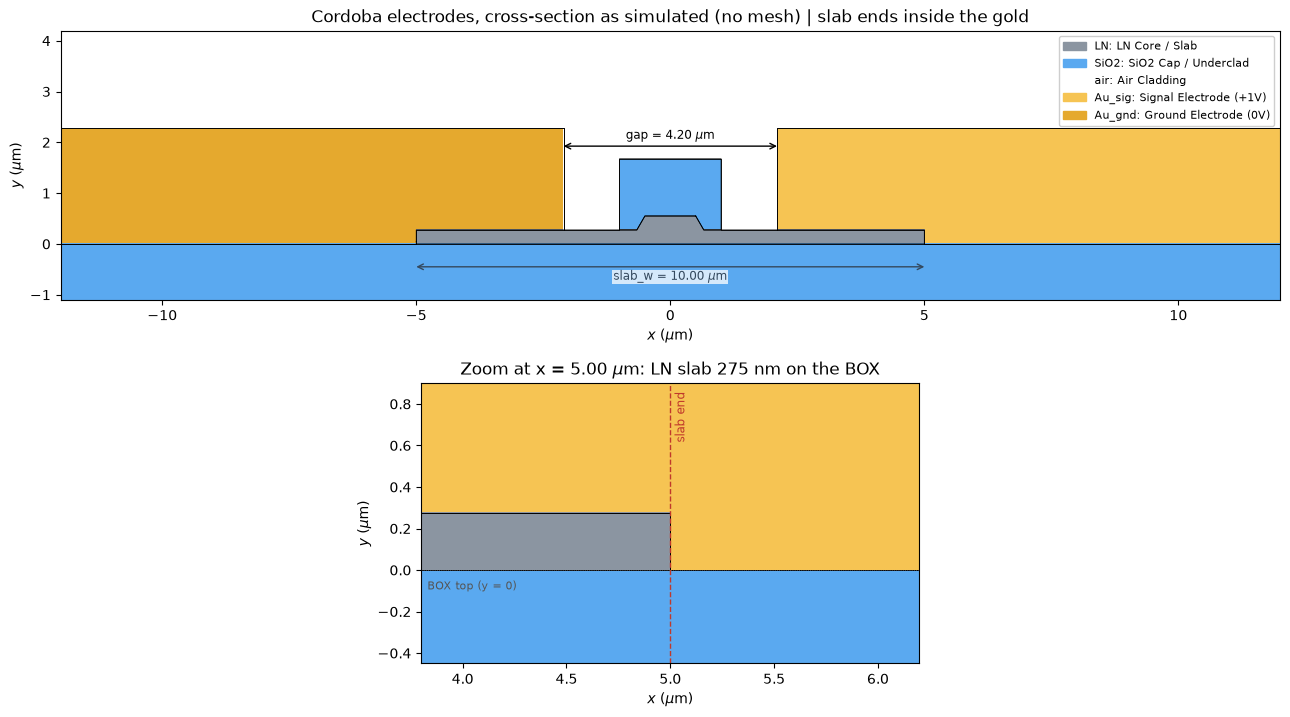

Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


...

Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


Transforming over 1000 elements to C_CONTIGUOUS.


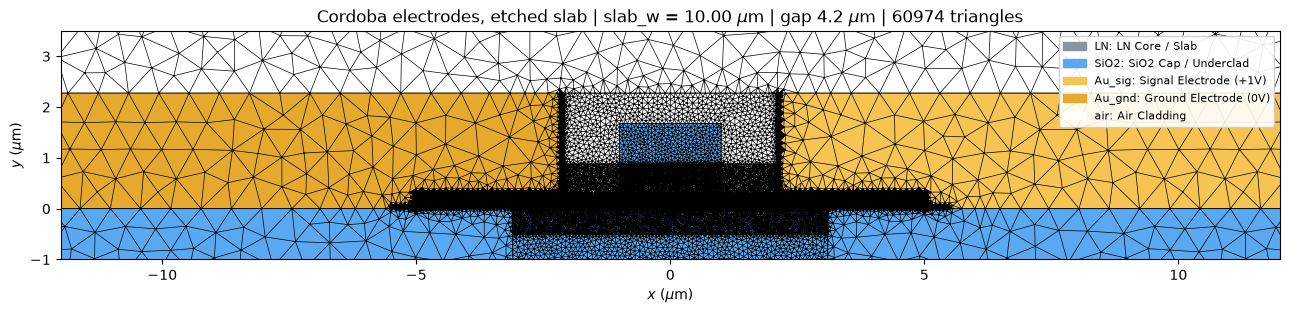

In [1]:
# %% [0] Geometry, Mesh & Material Configuration  --  CORDOBA (NON-LIFTED) ELECTRODES, ETCHED LN SLAB
#
#   Legacy Cordoba cross-section: two flat gold electrodes (EL_W = 30 um wide,
#   MTX = 2 um thick) sitting directly on the LN slab, gap GAP between them.
#   New: the LN slab can be fully etched outside a width SLAB_W centred on the
#   rib.  Wherever the slab is etched the gold fills the etched region down to
#   the BOX (the gold top stays at SLAB_H + MTX), and air fills it in the gap.
#
#   Regimes, set by the slab edge x_s = SLAB_W / 2:
#     x_s <  GAP/2                   slab ends in the air gap (narrower than the gap)
#     GAP/2 < x_s < GAP/2 + EL_W     slab ends INSIDE the gold (wrapped by gold)
#     x_s >= DEV_W/2                 no etch: the slab spans the whole domain (original design)
#
#   Materials, mesher fix, gold skin and corner refinement are identical to the
#   etched Lisbon-lifted cell (cell0_etched.py), so the two designs differ only in
#   the electrode shape above the slab.
import warnings
from collections import OrderedDict
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from shapely.affinity import scale as _scale
from shapely.geometry import Polygon, MultiPolygon, box
from shapely.ops import unary_union
from skfem import MeshTri
from femwell.mesh import mesh_from_OrderedDict

warnings.filterwarnings("ignore")

# ------------------------------------------------------------------------------
# femwell bug fix.  mesh_from_OrderedDict() tries to switch off gmsh's
# "extend mesh size from boundary" with `gmsh.model.mesh.MeshSizeExtendFromBoundary = 0`,
# which only sets a Python attribute: the gmsh option is never changed.  This
# wrapper applies the options femwell intended, so the mesh follows `resolutions`.
import gmsh
if not getattr(gmsh.model.mesh.field, "_size_fix", False):
    _orig_set_bg = gmsh.model.mesh.field.setAsBackgroundMesh

    def _set_bg_fixed(tag):
        _orig_set_bg(tag)
        gmsh.option.setNumber("Mesh.MeshSizeExtendFromBoundary", 0)
        gmsh.option.setNumber("Mesh.MeshSizeFromPoints", 0)
        gmsh.option.setNumber("Mesh.MeshSizeFromCurvature", 0)

    gmsh.model.mesh.field.setAsBackgroundMesh = _set_bg_fixed
    gmsh.model.mesh.field._size_fix = True

# ============================================================
# 1. FIXED PHYSICAL & GEOMETRIC PARAMETERS
# ============================================================
wl = 1.575          # um
wl_m = wl * 1e-6
k0 = 2.0 * np.pi / wl               # 1/um
k0_m = k0 * 1e6                     # 1/m
L_cm = 1.0          # cm
V_bias = 1.0        # V
r33 = 30.8e-12      # m/V
n_guess = 1.8755
num_modes_search = 8

# Geometry Dimensions (um), y = 0 at the BOX / LN interface
BOX_H = 4.7
TECN = 0.550
WG_H = 0.275
SLAB_H = TECN - WG_H                # 0.275 um LN slab
WG_TOP = 1.0
ALPHA = 60.0
GAP = 4.2
EL_W = 30.0         # 30 um physical width to dissipate lateral SPP mode
MTX = 2.0           # electrode thickness above the slab
MARGIN = 5.0        # air/BOX beyond each electrode
CLAD_H = 15.0       # air above the slab
CAP_W = 2.0
CAP_H = 1.40
SLAB_W = 10.0       # total width of the LN slab left after the full etch;
                    # >= DEV_W (e.g. 1e3) = no etch, the original Cordoba design

basetta = WG_H / np.tan(np.deg2rad(ALPHA))
WG_BOTTOM = WG_TOP + 2.0 * basetta
X_EL_OUT = GAP / 2.0 + EL_W                 # 32.1 um outer edge of the electrode
DEV_W = 2.0 * X_EL_OUT + 2.0 * MARGIN       # 74.2 um (= 2 EL_W + GAP + 10)
ETCHED = SLAB_W < DEV_W
SLAB_EXT = (min(SLAB_W, DEV_W) - GAP) / 2.0     # slab edge beyond the gap edge (per side)
assert CAP_W > WG_BOTTOM and GAP > CAP_W and SLAB_W > CAP_W, "rib / cap / gap inconsistent"
assert not ETCHED or SLAB_W / 2.0 < X_EL_OUT - 1.0, "etched slab must end in the gap or inside the gold"

# ---- Material dispersion: every optical constant is computed at `wl` ---------
def n_LN(lam):
    """Congruent LiNbO3, Zelmon et al., JOSA B 14, 3319 (1997).  Returns (ne, no)."""
    l2 = lam ** 2
    ne_ = np.sqrt(1 + 2.9804 * l2 / (l2 - 0.02047) + 0.5981 * l2 / (l2 - 0.0666)
                  + 8.9543 * l2 / (l2 - 416.08))
    no_ = np.sqrt(1 + 2.6734 * l2 / (l2 - 0.01764) + 1.2290 * l2 / (l2 - 0.05914)
                  + 12.614 * l2 / (l2 - 474.6))
    return ne_, no_


def n_SiO2(lam):
    """Fused silica, Malitson, JOSA 55, 1205 (1965)."""
    l2 = lam ** 2
    return np.sqrt(1 + 0.6961663 * l2 / (l2 - 0.0684043 ** 2)
                   + 0.4079426 * l2 / (l2 - 0.1162414 ** 2)
                   + 0.8974794 * l2 / (l2 - 9.896161 ** 2))


# Gold: Johnson & Christy, PRB 6, 4370 (1972), (lambda um, n, k); eps = (n - i k)^2
# interpolated linearly in photon energy.  exp(+jwt): Im(eps) < 0 is loss.
_AU_JC = np.array([
    (0.617, 0.21, 3.272), (0.659, 0.14, 3.697), (0.705, 0.13, 4.103),
    (0.756, 0.14, 4.542), (0.821, 0.16, 5.083), (0.892, 0.17, 5.663),
    (0.984, 0.22, 6.350), (1.088, 0.27, 7.150), (1.216, 0.35, 8.145),
    (1.393, 0.43, 9.519), (1.610, 0.56, 11.210), (1.937, 0.92, 13.780)])


def eps_Au_JC(lam):
    lam_t, n_t, k_t = _AU_JC.T
    assert lam_t.min() <= lam <= lam_t.max(), "wavelength outside the J&C table"
    E_t = 1.239842 / lam_t
    eps_t = (n_t - 1j * k_t) ** 2
    E = 1.239842 / lam
    return complex(np.interp(E, E_t[::-1], eps_t.real[::-1]),
                   np.interp(E, E_t[::-1], eps_t.imag[::-1]))


ne, no = n_LN(wl)
n_sio2 = n_SiO2(wl)
eps_au = eps_Au_JC(wl)
print(f"[materials @ {wl*1e3:.0f} nm] LN ne={ne:.6f} no={no:.6f} | "
      f"SiO2 n={n_sio2:.6f} | Au eps={eps_au.real:.2f}{eps_au.imag:+.2f}j")

# ---- Mesh scales (same as the etched lifted cell) -----------------------------
h_core = 0.040
h_skin = 0.012                      # gold on LN: the SPP decays into Au in ~22 nm
SKIN_T = 0.070                      # gold shell resolving the ~23 nm optical skin depth
BOT_SKIN_L = 0.5                    # shell on gold-on-BOX beyond an etched slab end
OUTER_WALL_SKIN_H = 0.5
CORNER_R = 0.050                    # corner patch half-size (um): metal/LN corners
h_corner = 0.006                    # mesh size inside the corner patches (um)
X_FINE_MIN = 8.0                    # fine slab mesh reaches at least |x| = 8 um

MATERIALS = {
    "LN":     {"color": "#8b95a1", "eps_dc": (28.0, 44.0), "eps_opt": (ne**2, no**2, no**2), "desc": "LN Core / Slab"},
    "SiO2":   {"color": "#5aa9f0", "eps_dc": (3.75, 3.75), "eps_opt": (n_sio2**2, n_sio2**2, n_sio2**2), "desc": "SiO2 Cap / Underclad"},
    "air":    {"color": "#ffffff", "eps_dc": (1.00, 1.00), "eps_opt": (1.00, 1.00, 1.00), "desc": "Air Cladding"},
    "Au_sig": {"color": "#f6c453", "eps_dc": (1.00, 1.00), "eps_opt": (eps_au, eps_au, eps_au), "desc": "Signal Electrode (+1V)"},
    "Au_gnd": {"color": "#e5a92e", "eps_dc": (1.00, 1.00), "eps_opt": (eps_au, eps_au, eps_au), "desc": "Ground Electrode (0V)"},
}

PREFIX_TO_MAT = [
    ("core", "LN"), ("cap", "SiO2"), ("slab", "LN"), ("box", "SiO2"),
    ("clad", "air"), ("elR", "Au_sig"), ("elL", "Au_gnd"),
]

def material_of(region_name):
    base = region_name.split("___")[0]
    for prefix, mat in PREFIX_TO_MAT:
        if base.startswith(prefix):
            return mat
    raise KeyError(f"Unknown material for region: {region_name}")

def mirror(p):
    return _scale(p, xfact=-1.0, yfact=1.0, origin=(0, 0))

def _areal(g, tol=1e-10):
    """Keep only the polygonal part of a shapely result (drops touching lines/points)."""
    if g.is_empty:
        return Polygon()
    if isinstance(g, Polygon):
        return g if g.area > tol else Polygon()
    parts = [p for p in getattr(g, "geoms", []) if isinstance(p, (Polygon, MultiPolygon))]
    parts = [q for p in parts for q in (p.geoms if isinstance(p, MultiPolygon) else [p])
             if q.area > tol]
    if not parts:
        return Polygon()
    return parts[0] if len(parts) == 1 else MultiPolygon(parts)

# ============================================================
# 2. GEOMETRY GENERATOR
# ============================================================
def build_polygons():
    xg = GAP / 2.0                                  # electrode inner edge
    x_out = X_EL_OUT                                # electrode outer edge
    x_dev_max = DEV_W / 2.0
    xs = min(SLAB_W / 2.0, x_dev_max)               # slab edge
    x_fine = max(X_FINE_MIN, min(xs, x_out) + 1.0)  # end of the finely meshed slab
    x_near = min(max(x_fine, min(xs, x_out)) + 15.0, x_dev_max - 2.0)

    y_slab_top = SLAB_H
    y_el_top = y_slab_top + MTX                     # 2.275
    y_cap_top = y_slab_top + CAP_H                  # 1.675
    y_clad_top = y_slab_top + CLAD_H
    y_fine_top = y_slab_top + 0.6                   # above this the mode is < -25 dB

    r_c = CORNER_R                                  # corner patches never touch
    if ETCHED:
        for _a in (xg, x_out):
            if abs(xs - _a) > 1e-9:
                r_c = min(r_c, abs(xs - _a) / 2.5)
        _d = abs(xs - (xg + 1.0))                   # fine-BOX block edge: a patch edge landing
        if 1e-9 < _d < r_c + 1e-9:                  # exactly on it makes a zero-length gmsh line
            r_c = 0.8 * _d
    assert r_c >= 0.01, f"slab edge {xs:.3f} um within 20 nm of a gold edge: not meshable"

    # ---- 1. LN: rib core and the (etched) slab ------------------------------
    core_poly = Polygon([
        (-WG_BOTTOM / 2.0, y_slab_top), (-WG_TOP / 2.0, y_slab_top + WG_H),
        (WG_TOP / 2.0, y_slab_top + WG_H), (WG_BOTTOM / 2.0, y_slab_top)])
    slab = box(-xs, 0.0, xs, y_slab_top)

    # ---- 2. SiO2 cap (2.0 x 1.4 um, on the slab) -----------------------------
    cap_poly = box(-CAP_W / 2.0, y_slab_top, CAP_W / 2.0, y_fine_top).difference(core_poly)
    cap_up = box(-CAP_W / 2.0, y_fine_top, CAP_W / 2.0, y_cap_top)

    # ---- 3. Electrode (right = signal): flat gold block, filling the etched
    #         slab region down to the BOX
    el_r = box(xg, 0.0, x_out, y_el_top).difference(slab)
    assert el_r.geom_type == "Polygon", "electrode is not a single body"

    # ---- 4. BOX (fine only in the top 0.5 um near the rib) -------------------
    box_near = box(-(xg + 1.0), -0.5, xg + 1.0, 0.0)
    box_mid = box(-(xg + 1.0), -1.5, xg + 1.0, -0.5)
    box_far = box(-x_dev_max, -BOX_H, x_dev_max, 0.0).difference(
        box(-(xg + 1.0), -1.5, xg + 1.0, 0.0))

    # ---- 5. Air: everything left above the BOX -------------------------------
    solids = unary_union([core_poly, slab, cap_poly, cap_up, el_r, mirror(el_r)])
    clad_all = box(-x_dev_max, 0.0, x_dev_max, y_clad_top).difference(solids)
    clad_gap = _areal(clad_all.intersection(box(-xg, 0.0, xg, y_fine_top)))
    clad_gap_up = _areal(clad_all.intersection(box(-xg, y_fine_top, xg, y_cap_top + 0.6)))
    clad_far = _areal(clad_all.difference(box(-xg, 0.0, xg, y_cap_top + 0.6)))

    base = OrderedDict()
    base["core"] = core_poly
    base["cap"] = cap_poly
    base["cap_up"] = cap_up
    base["elR_bulk"] = el_r
    base["elL_bulk"] = mirror(el_r)
    base["slab_fine"] = _areal(slab.intersection(box(-x_fine, 0.0, x_fine, y_slab_top)))
    base["slab_mid"] = _areal(slab.intersection(box(-x_near, 0.0, x_near, y_slab_top))
                              .difference(box(-x_fine, 0.0, x_fine, y_slab_top)))
    base["slab_far"] = _areal(slab.difference(box(-x_near, 0.0, x_near, y_slab_top)))
    base["box_near"] = box_near
    base["box_mid"] = box_mid
    base["box_far"] = box_far
    base["clad_gap"] = clad_gap
    base["clad_gap_up"] = clad_gap_up
    base["clad_far"] = clad_far

    # ---- 6. Refinement zones -------------------------------------------------
    # 6a. corner patches where gold touches the LN slab
    pts = []
    if xs > xg + 1e-9:
        pts.append((xg, y_slab_top))                 # inner corner: gold / LN / air
    else:
        pts.append((xg, 0.0))                        # gold foot on the BOX (slab_w <= gap)
    if xg + 1e-9 < xs < x_out - 1e-9:
        pts += [(xs, y_slab_top), (xs, 0.0)]         # slab end wrapped by gold
    elif xs >= x_out:
        pts.append((x_out, y_slab_top))              # outer corner: gold / LN / air (no etch)
    patches_r = unary_union([box(px - r_c, py - r_c, px + r_c, py + r_c) for px, py in pts])
    patches = unary_union([patches_r, mirror(patches_r)])

    # 6b. gold skin: within SKIN_T of the LN slab, the inner wall (full height),
    #     the foot of the outer wall, and BOT_SKIN_L of gold-on-BOX beyond an
    #     etched slab end.
    x_e = max(xs, xg)
    skin_zone_r = unary_union([
        slab.buffer(SKIN_T, join_style=2),
        box(xg, 0.0, xg + SKIN_T, y_el_top),
        box(x_out - SKIN_T, 0.0, x_out, y_slab_top + OUTER_WALL_SKIN_H),
        box(x_e, 0.0, min(x_e + BOT_SKIN_L, x_out), SKIN_T) if x_e < x_out else Polygon(),
    ])
    skin_zone = unary_union([skin_zone_r, mirror(skin_zone_r)])

    polys = OrderedDict()
    for name, reg in base.items():
        if reg.is_empty:
            continue
        pc = _areal(reg.intersection(patches))
        if not pc.is_empty:
            polys[name + "_corner"] = pc
        reg = _areal(reg.difference(patches))
        if name.startswith("el"):
            sk = _areal(reg.intersection(skin_zone))
            polys[name.replace("bulk", "skin")] = sk
            reg = _areal(reg.difference(skin_zone))
        if not reg.is_empty:
            polys[name] = reg

    return polys, y_clad_top

# ============================================================
# 3. MESH GENERATION & RESOLUTION SETUP
# ============================================================
polygons, Y_TOP = build_polygons()

_base_res = {
    "core":        (h_core, 0.30),
    "cap":         (0.035, 0.30),
    "cap_up":      (0.080, 0.30),
    "clad_gap":    (0.040, 0.30),
    "clad_gap_up": (0.100, 0.30),
    "slab_fine":   (0.025, 0.30),
    "slab_mid":    (0.110, 0.40),
    "slab_far":    (0.150, 0.50),
    "box_near":    (0.040, 0.30),
    "box_mid":     (0.100, 0.30),
    "box_far":     (0.800, 1.00),
    "elR_bulk":    (0.800, 0.50),
    "elL_bulk":    (0.800, 0.50),
    "elR_skin":    (h_skin, 0.20),
    "elL_skin":    (h_skin, 0.20),
    "clad_far":    (0.800, 1.00),
}
resolutions = {}
for _k in polygons:
    if _k.endswith("_corner"):
        resolutions[_k] = {"resolution": h_corner, "distance": 0.10}
    else:
        _r, _d = _base_res[_k]
        resolutions[_k] = {"resolution": _r, "distance": _d}

# ---- Validity / consistency assertions ---------------------------------------
_names = list(polygons)
for _n, _p in polygons.items():
    assert _p.is_valid and not _p.is_empty and _p.area > 1e-12, f"degenerate region {_n}"
for _i in range(len(_names)):
    for _j in range(_i + 1, len(_names)):
        _ov = polygons[_names[_i]].intersection(polygons[_names[_j]]).area
        assert _ov < 1e-10, f"overlap {_names[_i]} & {_names[_j]}: {_ov:.2e}"
_tot = sum(p.area for p in polygons.values())
assert abs(_tot - DEV_W * (BOX_H + Y_TOP)) < 1e-8, "tiling gap"

_regime = ("no etch: slab across the whole domain (original Cordoba)" if not ETCHED else
           "slab ends in the air gap" if SLAB_EXT < -1e-9 else
           "slab ends at the gold inner edge" if abs(SLAB_EXT) < 1e-9 else
           "slab ends inside the gold")
print(f"[geometry OK] {len(polygons)} regions tile exactly")
print(f"              SLAB_W {min(SLAB_W, DEV_W):.2f} um (edge {SLAB_EXT:+.2f} um from the gap edge): {_regime}")
print(f"              gap {GAP:.2f} um | flat electrodes {EL_W:.0f} x {MTX:.1f} um, gold out to x = {X_EL_OUT:.2f} um")

raw_mesh = mesh_from_OrderedDict(
    polygons,
    resolutions=resolutions,
    default_resolution_min=0.5 * min(h_skin, h_corner),
    default_resolution_max=0.6,
)
skfem_mesh = MeshTri(raw_mesh.points[:, :2].T, raw_mesh.cells_dict["triangle"].T)
tri_subdomains = raw_mesh.cell_data_dict["gmsh:physical"]["triangle"]
name_to_id = {
    name: data[0] if hasattr(data, "__getitem__") else data
    for name, data in raw_mesh.field_data.items()
}

mat_of_el = np.empty(skfem_mesh.nelements, dtype=object)
for raw_name, s_id in name_to_id.items():
    if raw_name.split("___")[0] in polygons:
        mat_of_el[tri_subdomains == s_id] = material_of(raw_name)

assert not np.any(mat_of_el == None), (  # noqa: E711
    f"{int(np.sum(mat_of_el == None))} unassigned elements")  # noqa: E711
print(f"[mesh OK] {skfem_mesh.nelements} triangles, {skfem_mesh.nvertices} vertices")

print("=" * 84)
print(f"{'CANONICAL MATERIAL':<28} | {'DC EPS (x, y)':<16} | {'OPTICAL EPS (xx, yy, zz)':<28}")
print("-" * 84)
for key, data in MATERIALS.items():
    dc_s = f"({data['eps_dc'][0]:.1f}, {data['eps_dc'][1]:.1f})"
    opt_val = data['eps_opt'][0]
    opt_s = f"({opt_val.real:.1f}{opt_val.imag:+.1f}j)" if np.iscomplex(opt_val) else f"({opt_val.real:.3f})"
    print(f"{data['desc']:<28} | {dc_s:<16} | {opt_s:<28}")
print("=" * 84)

# ---- Cross-section WITHOUT the mesh (material the solver assigns to each triangle)
from matplotlib.colors import ListedColormap

_mkeys = list(MATERIALS)
_midx = np.array([_mkeys.index(m) for m in mat_of_el], dtype=float)
_mcmap = ListedColormap([MATERIALS[m]["color"] for m in _mkeys])
_by_mat = {}
for _n, _p in polygons.items():
    _by_mat.setdefault(material_of(_n), []).append(_p)
_mat_shapes = {m: unary_union(v) for m, v in _by_mat.items()}


def _draw_materials(ax):
    ax.tripcolor(skfem_mesh.p[0], skfem_mesh.p[1], skfem_mesh.t.T, facecolors=_midx,
                 cmap=_mcmap, vmin=-0.5, vmax=len(_mkeys) - 0.5,
                 edgecolors="face", linewidth=0.0, antialiased=False)
    for _shape in _mat_shapes.values():
        for _part in (_shape.geoms if hasattr(_shape, "geoms") else [_shape]):
            for _ring in [_part.exterior, *_part.interiors]:
                _xy = np.asarray(_ring.coords)
                ax.plot(_xy[:, 0], _xy[:, 1], color="k", lw=0.6)


def _dim(ax, x0, x1, y, label, color="k", above=True):
    ax.annotate("", (x0, y), (x1, y),
                arrowprops=dict(arrowstyle="<->", color=color, lw=1.0, shrinkA=0, shrinkB=0))
    ax.text(0.5 * (x0 + x1), y + (0.08 if above else -0.08), label, color=color, fontsize=8.5,
            ha="center", va="bottom" if above else "top",
            bbox=dict(fc="white", ec="none", alpha=0.75, pad=0.6))


_xs, _xg = min(SLAB_W, DEV_W) / 2.0, GAP / 2.0
fig, (ax_a, ax_b) = plt.subplots(2, 1, figsize=(13, 7.4), gridspec_kw=dict(height_ratios=[1.2, 1]))
_draw_materials(ax_a)
_xl = max(12.0, min(_xs, X_EL_OUT) + 2.0)
if ETCHED:
    _dim(ax_a, -_xs, _xs, -0.45, rf"slab_w = {SLAB_W:.2f} $\mu$m", color="#34495e", above=False)
_dim(ax_a, -_xg, _xg, SLAB_H + MTX - 0.35, rf"gap = {GAP:.2f} $\mu$m")
ax_a.legend(handles=[mpatches.Patch(color=MATERIALS[m]["color"], label=f"{m}: {MATERIALS[m]['desc']}")
                     for m in _mkeys if m in _mat_shapes],
            loc="upper right", framealpha=0.95, fontsize=8)
ax_a.set_xlim(-_xl, _xl); ax_a.set_ylim(-1.1, 4.2); ax_a.set_aspect("equal")
ax_a.set_xlabel(r"$x$ ($\mu$m)"); ax_a.set_ylabel(r"$y$ ($\mu$m)")
ax_a.set_title(rf"Cordoba electrodes, cross-section as simulated (no mesh) | {_regime}")

_draw_materials(ax_b)
_zc = _xs if ETCHED else _xg
_zx0, _zx1 = _zc - 1.2, _zc + 1.2
for _xv, _lab, _c in [(_xg, "gold inner edge", "#b9770e"), (_xs, "slab end", "#c0392b")]:
    if _zx0 < _xv < _zx1 and (ETCHED or _xv == _xg):
        ax_b.axvline(_xv, color=_c, ls="--", lw=1.0)
        ax_b.text(_xv + 0.02, 0.86, _lab, color=_c, fontsize=8.5, rotation=90, va="top")
ax_b.axhline(0.0, color="#555", lw=0.6, ls=":")
ax_b.text(_zx0 + 0.03, -0.05, "BOX top (y = 0)", fontsize=8, va="top", color="#555")
ax_b.set_xlim(_zx0, _zx1); ax_b.set_ylim(-0.45, 0.9); ax_b.set_aspect("equal")
ax_b.set_xlabel(r"$x$ ($\mu$m)"); ax_b.set_ylabel(r"$y$ ($\mu$m)")
ax_b.set_title(rf"Zoom at x = {_zc:.2f} $\mu$m: LN slab {SLAB_H*1e3:.0f} nm on the BOX")
plt.tight_layout()
plt.show()

# ---- Cross-section with the mesh ----------------------------------------------
fig, ax = plt.subplots(figsize=(13, 4.5))
legend_patches = []
seen = set()

for raw_name, s_id in name_to_id.items():
    if raw_name.split("___")[0] not in polygons:
        continue
    mat_key = material_of(raw_name)
    col = MATERIALS[mat_key]["color"]
    elem_idx = np.where(tri_subdomains == s_id)[0]
    if elem_idx.size == 0:
        continue
    sub_mesh = MeshTri(skfem_mesh.p, skfem_mesh.t[:, elem_idx])
    sub_mesh.plot(np.zeros(sub_mesh.nelements), ax=ax, shading="flat",
                  cmap=plt.matplotlib.colors.ListedColormap([col]))
    sub_mesh.draw(ax=ax, color="black", lw=0.15)
    if mat_key not in seen:
        legend_patches.append(mpatches.Patch(color=col, label=f"{mat_key}: {MATERIALS[mat_key]['desc']}"))
        seen.add(mat_key)

ax.legend(handles=legend_patches, loc="upper right", framealpha=0.9, fontsize=8)
ax.set_title(rf"Cordoba electrodes, etched slab | slab_w = {min(SLAB_W, DEV_W):.2f} $\mu$m | "
             rf"gap {GAP:.1f} $\mu$m | {skfem_mesh.nelements} triangles")
ax.set_xlim([-_xl, _xl])
ax.set_ylim([-1.0, 3.5])
ax.set_xlabel(r"$x$ ($\mu$m)")
ax.set_ylabel(r"$y$ ($\mu$m)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

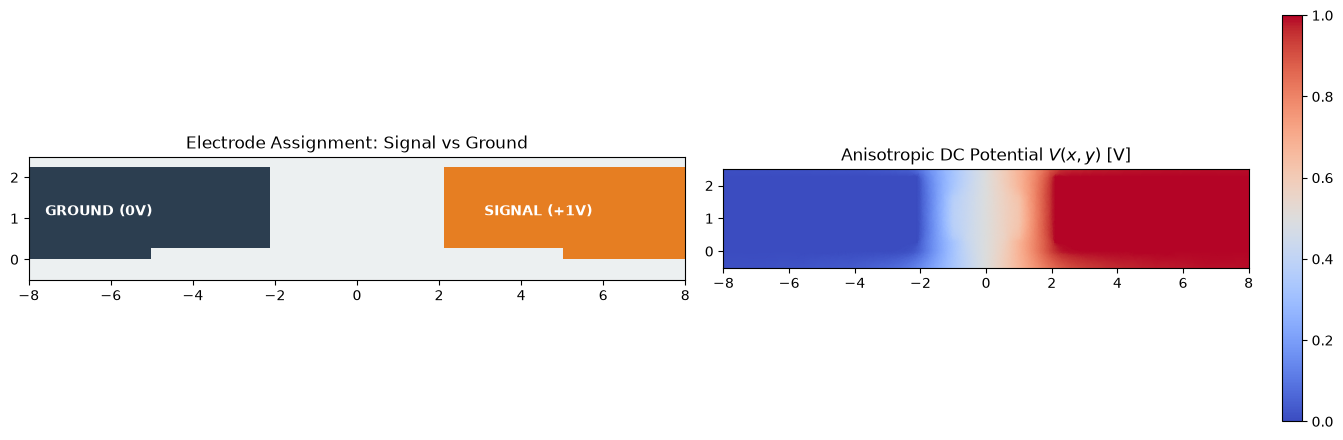

In [2]:
# %% [1] Anisotropic DC Electrostatics
from skfem import Basis, ElementTriP0, ElementTriP1, BilinearForm, asm, condense, solve
from skfem.helpers import grad

basis_dc = Basis(skfem_mesh, ElementTriP1(), intorder=4)
basis_p0 = Basis(skfem_mesh, ElementTriP0(), intorder=4)

eps_dc_x = np.array([MATERIALS[m]["eps_dc"][0] for m in mat_of_el], dtype=float)
eps_dc_y = np.array([MATERIALS[m]["eps_dc"][1] for m in mat_of_el], dtype=float)

@BilinearForm
def laplace_aniso(u, v, w):
    return w.eps_x * grad(u)[0] * grad(v)[0] + w.eps_y * grad(u)[1] * grad(v)[1]

K = asm(
    laplace_aniso,
    basis_dc,
    eps_x=basis_p0.interpolate(eps_dc_x),
    eps_y=basis_p0.interpolate(eps_dc_y),
)

sig_elements = np.where(mat_of_el == "Au_sig")[0]
gnd_elements = np.where(mat_of_el == "Au_gnd")[0]

dofs_signal = basis_dc.get_dofs(elements=sig_elements).all()
dofs_ground = basis_dc.get_dofs(elements=gnd_elements).all()
dofs_dirichlet = np.unique(np.concatenate([dofs_signal, dofs_ground]))

u_dirichlet = np.zeros(basis_dc.N)
u_dirichlet[dofs_signal] = V_bias
u_dirichlet[dofs_ground] = 0.0

K_c, f_c, u_c, I = condense(K, np.zeros(basis_dc.N), x=u_dirichlet, D=dofs_dirichlet)
potential_nodes = u_c.copy()
potential_nodes[I] = solve(K_c, f_c)

grad_V = basis_dc.interpolate(potential_nodes).grad
Ex_dc = -np.mean(grad_V[0], axis=-1) if grad_V.ndim == 3 else -grad_V[0]

# Diagnostic plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax0 = axes[0]
electrode_field = np.zeros(skfem_mesh.nelements)
electrode_field[mat_of_el == "Au_sig"] = 1.0
electrode_field[mat_of_el == "Au_gnd"] = -1.0

skfem_mesh.plot(electrode_field, ax=ax0, shading="flat", cmap=plt.matplotlib.colors.ListedColormap(["#2c3e50", "#ecf0f1", "#e67e22"]))
ax0.text(GAP / 2 + 1.0, SLAB_H + 0.8, "SIGNAL (+1V)", color="white", fontweight="bold")
ax0.text(-GAP / 2 - 5.5, SLAB_H + 0.8, "GROUND (0V)", color="white", fontweight="bold")
ax0.set_title("Electrode Assignment: Signal vs Ground")
ax0.set_xlim([-8.0, 8.0])
ax0.set_ylim([-0.5, 2.5])
ax0.set_aspect("equal")

ax1 = axes[1]
skfem_mesh.plot(potential_nodes, ax=ax1, shading="gouraud", cmap="coolwarm", colorbar=True)
ax1.set_title(r"Anisotropic DC Potential $V(x, y)$ [V]")
ax1.set_xlim([-8.0, 8.0])
ax1.set_ylim([-0.5, 2.5])
ax1.set_aspect("equal")

plt.tight_layout()
plt.show()

In [3]:
# %% [2] Optical Eigensolver (N1 x P1 Elements)
import scipy.constants
from skfem import ElementTriN1, ElementTriP0, ElementTriP1, BilinearForm, solve, condense
from skfem.helpers import curl, dot, grad
from skfem.utils import solver_eigen_scipy
from femwell.maxwell.waveguide import Mode, Modes, calculate_hfield, calculate_overlap

def compute_modes_anisotropic(
    basis_epsilon_r,
    eps_xx,
    eps_yy,
    eps_zz,
    wavelength,
    num_modes=8,
    n_guess=1.8755,
):
    c0 = scipy.constants.speed_of_light
    k0_val = 2.0 * np.pi / wavelength
    element = ElementTriN1() * ElementTriP1()
    basis = basis_epsilon_r.with_element(element)
    basis_eps = basis.with_element(basis_epsilon_r.elem)

    @BilinearForm(dtype=complex)
    def aform(e_t, e_z, v_t, v_z, w):
        return (
            curl(e_t) * curl(v_t) / k0_val**2
            - (w.eps_xx * e_t[0] * v_t[0] + w.eps_yy * e_t[1] * v_t[1])
            + dot(grad(e_z), v_t)
            + (w.eps_xx * e_t[0] * grad(v_z)[0] + w.eps_yy * e_t[1] * grad(v_z)[1])
            - w.eps_zz * e_z * v_z * k0_val**2
        )

    @BilinearForm(dtype=complex)
    def bform(e_t, e_z, v_t, v_z, w):
        return -dot(e_t, v_t) / k0_val**2

    A = aform.assemble(
        basis,
        eps_xx=basis_eps.interpolate(eps_xx),
        eps_yy=basis_eps.interpolate(eps_yy),
        eps_zz=basis_eps.interpolate(eps_zz),
    )
    B = bform.assemble(basis)

    bnd_dofs = basis.get_dofs(facets=skfem_mesh.boundary_facets())
    lams, xs = solve(
        *condense(-A, -B, D=bnd_dofs, x=basis.zeros(dtype=complex)),
        solver=solver_eigen_scipy(k=num_modes, sigma=k0_val**2 * n_guess**2),
    )

    xs[basis.split_indices()[1], :] /= 1j * np.sqrt(lams[np.newaxis, :] / k0_val**4)

    hs = []
    omega = k0_val * (c0 * 1e6)
    for i, lam in enumerate(lams):
        H = calculate_hfield(basis, xs[:, i], np.sqrt(lam), omega=omega)
        power = calculate_overlap(basis, xs[:, i], H, basis, xs[:, i], H)
        xs[:, i] /= np.sqrt(power)
        H /= np.sqrt(power)
        hs.append(H)

    return Modes(
        modes=[
            Mode(
                frequency=(c0 * 1e6) / wavelength,
                k=np.sqrt(lams[i]),
                basis_epsilon_r=basis_epsilon_r,
                epsilon_r=eps_xx,
                basis=basis,
                E=xs[:, i],
                H=hs[i],
            )
            for i in range(num_modes)
        ]
    )

eps_xx = np.array([MATERIALS[m]["eps_opt"][0] for m in mat_of_el], dtype=complex)
eps_yy = np.array([MATERIALS[m]["eps_opt"][1] for m in mat_of_el], dtype=complex)
eps_zz = np.array([MATERIALS[m]["eps_opt"][2] for m in mat_of_el], dtype=complex)

basis_epsilon_r = Basis(skfem_mesh, ElementTriP0(), intorder=4)

import time
t_eig0 = time.time()
modes = compute_modes_anisotropic(
    basis_epsilon_r,
    eps_xx,
    eps_yy,
    eps_zz,
    wavelength=wl,
    num_modes=num_modes_search,
    n_guess=n_guess,
)
print(f"Eigensolver complete in {time.time() - t_eig0:.1f}s: computed {len(modes)} optical modes around n_guess = {n_guess}.")

Eigensolver complete in 26.2s: computed 8 optical modes around n_guess = 1.8755.


Idx  | Re(neff)   | Im(neff)     | TE %     | Core Pwr % | Unipolarity 
----------------------------------------------------------------------------------


0    | 1.88403    | -8.88e-07    | 95.26  % | 36.68    % | 1.0000      


1    | 1.86123    | -1.09e-02    | 9.50   % | 0.00     % | 0.9590      


2    | 1.86122    | -1.09e-02    | 9.50   % | 0.00     % | 1.0000      


3    | 1.85367    | -4.40e-09    | 1.85   % | 31.72    % | 0.0012      


4    | 1.96606    | -1.06e-02    | 6.74   % | 0.00     % | 1.0000      


5    | 1.96605    | -1.06e-02    | 6.74   % | 0.00     % | 1.0000      


6    | 1.74444    | -1.76e-04    | 87.04  % | 15.87    % | 0.0000      


7    | 1.71921    | -1.02e-02    | 20.08  % | 0.08     % | 0.8277      


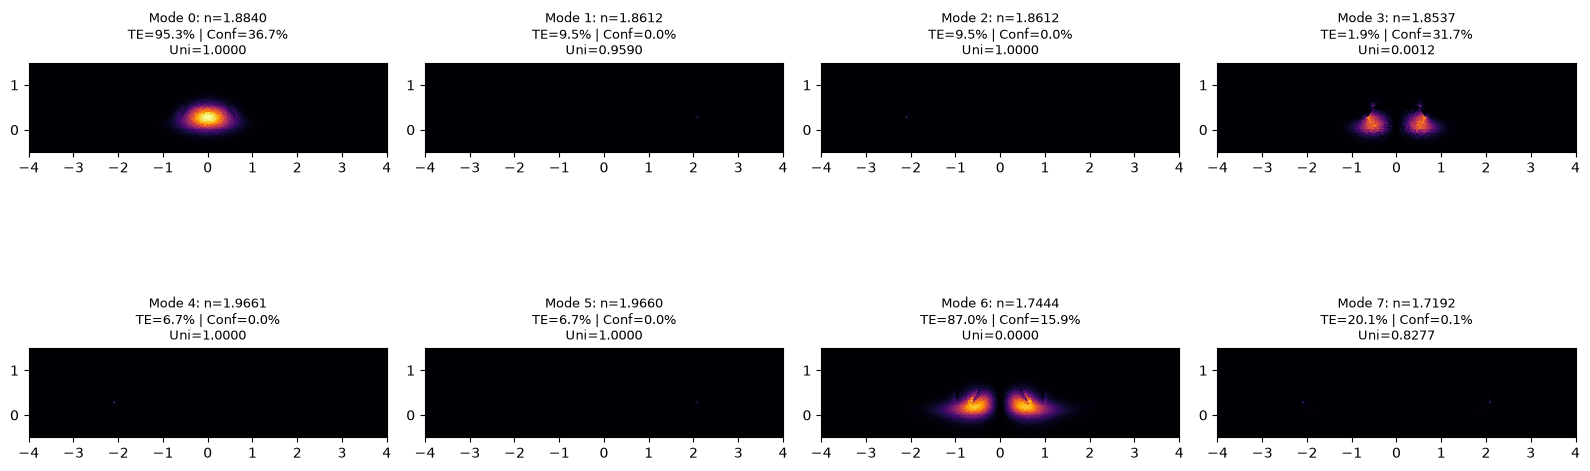

In [4]:
# %% [3] High-Precision Diagnostics & Mode Gallery
from skfem import Functional

core_ids = [s_id for name, s_id in name_to_id.items() if name.split("___")[0] == "core"]
is_core = np.zeros(skfem_mesh.nelements, dtype=float)
is_core[np.isin(tri_subdomains, core_ids)] = 1.0
is_core_field = basis_p0.interpolate(is_core)

@Functional(dtype=complex)
def _px(w):
    return np.abs(w["E"][0][0]) ** 2

@Functional(dtype=complex)
def _ptot(w):
    return (
        np.abs(w["E"][0][0]) ** 2
        + np.abs(w["E"][0][1]) ** 2
        + np.abs(w["E"][1]) ** 2
    )

@Functional(dtype=complex)
def _p_core(w):
    return w["is_core"] * (
        np.abs(w["E"][0][0]) ** 2
        + np.abs(w["E"][0][1]) ** 2
        + np.abs(w["E"][1]) ** 2
    )

@Functional(dtype=complex)
def _ex_core_signed(w):
    return w["is_core"] * np.real(w["E"][0][0])

@Functional(dtype=complex)
def _ex_core_abs(w):
    return w["is_core"] * np.abs(np.real(w["E"][0][0]))

mode_diagnostics = []

print("=" * 82)
print(f"{'Idx':<4} | {'Re(neff)':<10} | {'Im(neff)':<12} | {'TE %':<8} | {'Core Pwr %':<10} | {'Unipolarity':<12}")
print("-" * 82)

for idx, mode in enumerate(modes):
    E_interp = mode.basis.interpolate(mode.E)

    P_x = np.real(_px.assemble(mode.basis, E=E_interp))
    P_tot = np.real(_ptot.assemble(mode.basis, E=E_interp))
    P_core = np.real(_p_core.assemble(mode.basis, E=E_interp, is_core=is_core_field))

    te_ratio = P_x / P_tot
    core_confinement = P_core / P_tot

    signed = np.real(_ex_core_signed.assemble(mode.basis, E=E_interp, is_core=is_core_field))
    absval = np.real(_ex_core_abs.assemble(mode.basis, E=E_interp, is_core=is_core_field))

    unipolarity = 0.0000 if absval < 1e-12 else np.abs(signed) / absval

    neff_val = complex(mode.k / k0)

    mode_diagnostics.append({
        "index": idx,
        "mode": mode,
        "neff": neff_val,
        "te_ratio": te_ratio,
        "core_conf": core_confinement,
        "unipolarity": unipolarity,
    })

    print(
        f"{idx:<4} | "
        f"{neff_val.real:<10.5f} | "
        f"{neff_val.imag:<12.2e} | "
        f"{te_ratio * 100:<7.2f}% | "
        f"{core_confinement * 100:<9.2f}% | "
        f"{unipolarity:<12.4f}"
    )

print("=" * 82)

# Full Mode Gallery Plot
cols = 4
rows = int(np.ceil(len(modes) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(16, 3.4 * rows))
axes = np.array(axes).flatten()

for idx, diag in enumerate(mode_diagnostics):
    ax = axes[idx]
    E_interp = diag["mode"].basis.interpolate(diag["mode"].E)
    Ex_elem = np.mean(np.abs(E_interp[0].value[0]) ** 2, axis=-1)

    skfem_mesh.plot(Ex_elem, ax=ax, shading="flat", cmap="inferno")
    title_str = (
        f"Mode {idx}: n={diag['neff'].real:.4f}\n"
        f"TE={diag['te_ratio']*100:.1f}% | Conf={diag['core_conf']*100:.1f}%\n"
        f"Uni={diag['unipolarity']:.4f}"
    )
    ax.set_title(title_str, fontsize=9)
    ax.set_xlim([-4.0, 4.0])
    ax.set_ylim([-0.5, 1.5])
    ax.set_aspect("equal")

for j in range(len(modes), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [5]:
# %% [4] Overlap Integral, Vpi*L & Optical Attenuation
from skfem import Functional

# Fundamental TE mode identification (highest index matching modal filters)
guided_cands = [
    d for d in mode_diagnostics
    if d["te_ratio"] >= 0.75 and d["core_conf"] >= 0.20 and d["unipolarity"] >= 0.85   # same filter as the etched Lisbon-lifted notebook
]

if not guided_cands:
    raise RuntimeError("Fundamental TE rib mode not found. Check n_guess or eigensolver outputs.")

guided_cands.sort(key=lambda x: x["neff"].real, reverse=True)
fund_diag = guided_cands[0]
chosen_idx = fund_diag["index"]
fund_mode = fund_diag["mode"]
n_eff = fund_diag["neff"]

# 1. Optical Attenuation (Ohmic Metal Loss matching COMSOL Att_Opt)
att_opt_dB_m = np.abs(20.0 * np.log10(np.e) * k0_m * np.imag(n_eff))
att_opt_dB_cm = att_opt_dB_m / 100.0

# 2. Electro-Optic Overlap Integral (Gamma)
ln_mask = (mat_of_el == "LN")
Ex_dc_ln = np.zeros(skfem_mesh.nelements, dtype=float)
Ex_dc_ln[ln_mask] = Ex_dc[ln_mask]
Ex_dc_ln_field = basis_p0.interpolate(Ex_dc_ln)

E_fund_interp = fund_mode.basis.interpolate(fund_mode.E)

@Functional(dtype=complex)
def _num(w): 
    return w["Ex_dc_ln"] * np.abs(w["E"][0][0]) ** 2

@Functional(dtype=complex)
def _den(w): 
    return np.abs(w["E"][0][0]) ** 2

num = np.real(_num.assemble(fund_mode.basis, E=E_fund_interp, Ex_dc_ln=Ex_dc_ln_field))
den = np.real(_den.assemble(fund_mode.basis, E=E_fund_interp))

overlap = (GAP / V_bias) * (num / den)
Vpi_L_m = (GAP * 1e-6 * wl_m) / (r33 * np.abs(overlap) * (ne**3) * 2.0)
Vpi_L_Vcm = Vpi_L_m * 100.0
Vpi = Vpi_L_Vcm / L_cm

# 3. Formatted Simulation Summary
print("=" * 55)
print("             ELECTRO-OPTIC SIMULATION RESULTS")
print("=" * 55)
print(f"Selected Mode Index:         {chosen_idx}")
print(f"Effective Index (neff):      {n_eff.real:.6f} + {n_eff.imag:.2e}j")
print(f"Optical Attenuation:         {att_opt_dB_cm:.4e} dB/cm  ({att_opt_dB_m:.4e} dB/m)")
print(f"Overlap Integral (Gamma):    {overlap:.4f}")
print(f"|Vpi * L|:                   {Vpi_L_Vcm:.4f} V*cm")
print(f"|Vpi| (for L = {L_cm} cm):        {Vpi:.4f} V")
print("=" * 55)

             ELECTRO-OPTIC SIMULATION RESULTS
Selected Mode Index:         0
Effective Index (neff):      1.884032 + -8.88e-07j
Optical Attenuation:         3.0770e-01 dB/cm  (3.0770e+01 dB/m)
Overlap Integral (Gamma):    -0.4855
|Vpi * L|:                   2.2670 V*cm
|Vpi| (for L = 1.0 cm):        2.2670 V
